# IMPORT LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# LOAD DATSET

In [3]:
fake = pd.read_csv("/content/Fake_News.csv", engine='python', on_bad_lines='skip')
true = pd.read_csv("/content/True_News.csv", engine='python', on_bad_lines='skip')

# MERGE BOTH DATASET

In [4]:
fake["is_fake"] = 1
true["is_fake"] = 0

In [5]:
df = pd.concat([fake, true], ignore_index=True)

# EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   is_fake  44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [7]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
is_fake,0


DATA LEAKAGE PREVETION

In [8]:
df['subject'].nunique()


8

In [9]:
df['subject'].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [10]:
pd.crosstab(df["subject"], df["is_fake"])

is_fake,0,1
subject,,
Government News,0,1570
Middle-east,0,778
News,0,9050
US_News,0,783
left-news,0,4459
politics,0,6841
politicsNews,11272,0
worldnews,10145,0


In [11]:
df_edited = df.drop(columns = ['date', 'subject'])

In [12]:
df_edited

,title,text,is_fake
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,1
...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,0
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",0
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,0
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,0


# HANDLING DUPLICATE

In [13]:
print(df.duplicated(subset=["text"]).sum())
print(df.duplicated(subset=["title"]).sum())
print(df.duplicated(subset=["title", "text"]).sum())

6252
6169
5793


In [14]:
conflict = df_edited.groupby(["title", "text"])["is_fake"].nunique()

conflict = conflict[conflict > 1]

print("Conflicting duplicates:", len(conflict))

Conflicting duplicates: 0


In [15]:
df_edited = df_edited.drop_duplicates(subset=["title", "text"])

In [16]:
df_edited.shape

(39105, 3)

In [17]:
print(df_edited.duplicated(subset=["text"]).sum())
print(df_edited.duplicated(subset=["title"]).sum())
print(df_edited.duplicated(subset=["title", "text"]).sum())

459
376
0


# DATA CLEANING

In [18]:
df_cleaned = df_edited.copy()
df_cleaned['Article_Text'] = df_edited['title'] + " " + df_edited['text']
df_cleaned.drop(columns = ['title' , 'text'] , inplace = True)

In [19]:
df_cleaned

,is_fake,Article_Text
0,1,Donald Trump Sends Out Embarrassing New Year’...
1,1,Drunk Bragging Trump Staffer Started Russian ...
2,1,Sheriff David Clarke Becomes An Internet Joke...
3,1,Trump Is So Obsessed He Even Has Obama’s Name...
4,1,Pope Francis Just Called Out Donald Trump Dur...
...,...,...
44893,0,'Fully committed' NATO backs new U.S. approach...
44894,0,LexisNexis withdrew two products from Chinese ...
44895,0,Minsk cultural hub becomes haven from authorit...
44896,0,Vatican upbeat on possibility of Pope Francis ...


In [20]:
df_cleaned['Article_Text'] = df_cleaned['Article_Text'].str.strip()

In [21]:
df_cleaned['Article_Text'] = df_cleaned['Article_Text'].apply(lambda x : x.lower())

In [22]:
import string
def remove_punct(text):
  return text.translate(str.maketrans('', '', string.punctuation))

df_cleaned['Article_Text'] = df_cleaned['Article_Text'].apply(remove_punct)

In [23]:
def remove_emojis(text):
  cleaned = ""
  for i in text:
    if(i.isascii()):
      cleaned += i
  return cleaned

df_cleaned['Article_Text'] = df_cleaned['Article_Text'].apply(remove_emojis)

In [24]:
def remove_extra_spaces(text):
    return " ".join(text.split())

df_cleaned["Article_Text"] = df_cleaned["Article_Text"].apply(remove_extra_spaces)

In [25]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [26]:
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    words = nltk.word_tokenize(text)

    cleaned_words = [
        lemmatizer.lemmatize(word, pos="v")
        for word in words
        if word not in stop_words
    ]

    return " ".join(cleaned_words)

df_cleaned["Article_Text"] = df_cleaned["Article_Text"].apply(preprocess_text)

# TFIDF IMPLEMENTAION

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_cleaned['Article_Text'], df_cleaned['is_fake'], test_size=0.2, random_state=42)


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [29]:
X_train_tfidf.shape

(31284, 189873)

MODEL TRAINING AND EVALUATION

In [30]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , precision_score , recall_score , f1_score

In [47]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': LinearSVC(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

result_df = pd.DataFrame(results)
result_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.929932,0.972753,0.870760,0.918935
1,Logistic Regression,0.987214,0.990659,0.981217,0.985915
2,SVM,0.994118,0.995776,0.991309,0.993538


# CROSS VALIDATION

In [32]:
cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_tfidf,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Scores": scores,
        "CV Mean": scores.mean(),
        "CV Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df["CV Scores"] = cv_df["CV Scores"].apply(lambda x: [round(i, 4) for i in x])
cv_df["CV Mean"] = cv_df["CV Mean"].round(4)
cv_df["CV Std"] = cv_df["CV Std"].round(4)

cv_df

,Model,CV Scores,CV Mean,CV Std
0,Naive Bayes,"[0.9258, 0.9281, 0.9286, 0.9182, 0.9254]",0.9252,0.0037
1,Logistic Regression,"[0.9867, 0.9858, 0.9834, 0.9823, 0.9827]",0.9842,0.0018
2,SVM,"[0.9923, 0.9934, 0.9923, 0.9909, 0.9933]",0.9925,0.0009


# CONFUSION MATRIX

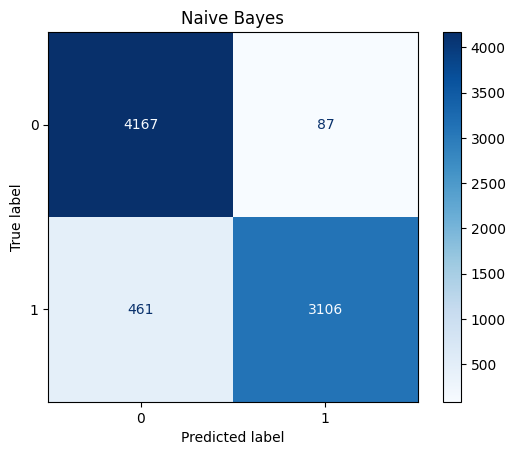

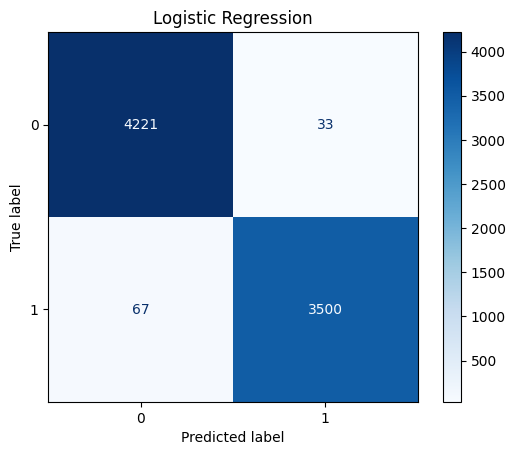

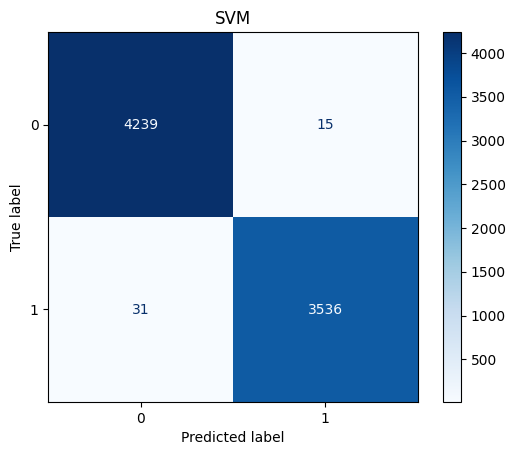

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in models.items():
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_tfidf,
        y_test,
        cmap="Blues"
    )

    plt.title(name)
    plt.show()

# ROC CURVE

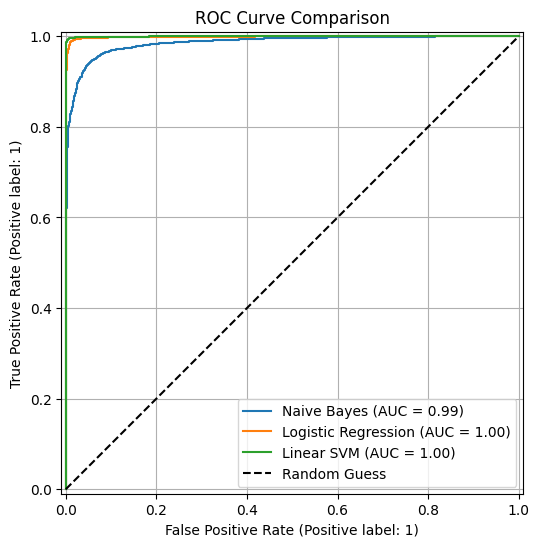

In [34]:
from sklearn.metrics import RocCurveDisplay


plt.figure(figsize=(8,6))

for name in ["Naive Bayes", "Logistic Regression"]:
    RocCurveDisplay.from_estimator(
        models[name],
        X_test_tfidf,
        y_test,
        ax=plt.gca(),
        name=name
    )

RocCurveDisplay.from_predictions(
    y_test,
    models["SVM"].decision_function(X_test_tfidf),
    name="Linear SVM",
    ax=plt.gca()
)

plt.plot([0,1],[0,1],'k--',label="Random Guess")

plt.title("ROC Curve Comparison")
plt.grid(True)
plt.legend()

plt.show()

# ACCURACY COMPARISON

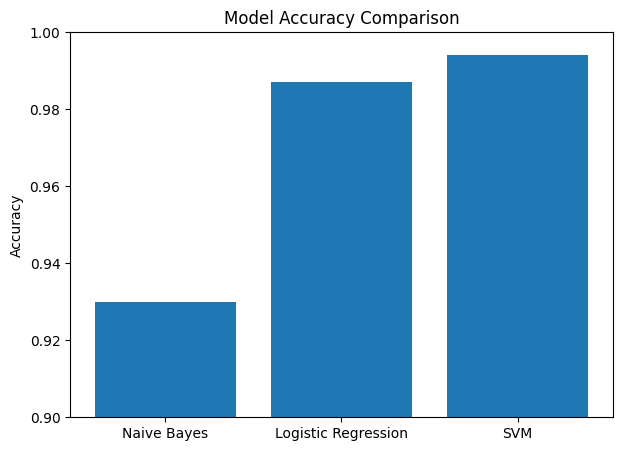

In [35]:
plt.figure(figsize=(7,5))

plt.bar(result_df["Model"], result_df["Accuracy"])

plt.ylim(0.9,1.0)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()


# TOP FEATURES(WORDS)[LOGISTIC REGERESSION]

In [36]:
feature_names = vectorizer.get_feature_names_out()

coef = models["Logistic Regression"].coef_[0]

top_fake = coef.argsort()[-20:]
top_real = coef.argsort()[:20]

In [37]:
print("Top words predicting Fake News\n")

for i in reversed(top_fake):
    print(feature_names[i], round(coef[i],3))

Top words predicting Fake News

video 9.81
image 8.72
via 8.584
gop 5.555
even 4.638
hillary 4.633
go 4.578
america 4.533
get 4.397
obama 4.387
like 4.331
mr 3.847
american 3.487
wire 3.439
watch 3.335
21st 3.154
rep 3.147
know 3.131
fact 3.104
claim 3.033


In [38]:
print("Top words predicting Real News\n")

for i in top_real:
    print(feature_names[i], round(coef[i],3))

Top words predicting Real News

reuters -22.0
say -18.347
us -6.087
washington -5.918
wednesday -5.478
tuesday -4.991
thursday -4.704
friday -4.621
monday -4.447
minister -4.338
republican -4.196
presidential -3.737
edt -3.487
dont -3.407
spokesman -3.376
nov -3.372
reporters -3.351
im -3.244
comment -3.069
statement -3.021


# Experimenting removing 'reuters' , 'say'

In [39]:
df_experiment = df_cleaned.copy()
df_experiment['Article_Text'] = df_experiment['Article_Text'].apply(lambda x: x.replace('reuters', ''))
df_experiment['Article_Text'] = df_experiment['Article_Text'].apply(lambda x: x.replace('say', ''))

In [44]:
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    df_experiment['Article_Text'],
    df_experiment['is_fake'],
    test_size=0.2,
    random_state=42
)

models2 = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': LinearSVC(random_state=42)
}

results = []

for name, clf in models2.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('model', clf)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

result_df_2 = pd.DataFrame(results)
print(result_df_2)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.927503   0.969043  0.868797  0.916186
1  Logistic Regression  0.982227   0.986932  0.973928  0.980387
2                  SVM  0.988876   0.991248  0.984301  0.987762


In [48]:
comparison_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],

    "Original Accuracy": result_df["Accuracy"].round(4),
    "Modified Accuracy": result_df_2["Accuracy"].round(4),
})

comparison_df["Accuracy Change"] = (
    comparison_df["Modified Accuracy"] -
    comparison_df["Original Accuracy"]
).round(4)


comparison_df

,Model,Original Accuracy,Modified Accuracy,Accuracy Change
0,Naive Bayes,0.9299,0.9275,-0.0024
1,Logistic Regression,0.9872,0.9822,-0.0050
2,SVM,0.9941,0.9889,-0.0052


Experiment: Effect of Removing Source-Specific Words

Feature importance analysis revealed that the words "Reuters" and "say" had unusually large coefficients and strongly influenced model predictions. To investigate potential source bias, these words were removed from the text corpus(dataset) and the models were retrained.

The results showed only a small reduction in accuracy (0.24%–0.52%), while all models continued to perform above 92%, with Linear SVM still achieving 98.89% accuracy. This suggests that although the removed words contributed to classification, the models primarily relied on broader linguistic patterns rather than memorizing a small set of source-specific terms. Therefore, the modified models are expected to generalize better to news articles from previously unseen publishers.

# Conclusion

This project developed a Fake News Detection system using classical Natural Language Processing (NLP) techniques and Machine Learning models. During exploratory data analysis, significant data leakage was identified in the `subject` column and removed to ensure a fair evaluation. Duplicate articles and conflicting duplicate labels were also detected and cleaned.

The text data was preprocessed through lowercasing, punctuation removal, emoji removal, stopword removal, and verb lemmatization before being transformed into numerical features using TF-IDF vectorization.

Three machine learning models were trained and evaluated:
- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine (SVM)

Among them, **Linear SVM achieved the best performance**, obtaining approximately **99.4% test accuracy** and **99.2% average cross-validation accuracy**, demonstrating excellent predictive performance and stability.

Feature importance analysis revealed that words such as **"Reuters" , "say"** strongly influenced the model. An additional experiment removed these source-specific words, resulting in only a slight decrease in accuracy while maintaining strong performance. This suggests that the model primarily learned meaningful linguistic patterns rather than relying solely on publisher-specific information.

Overall, the project demonstrates a complete classical NLP pipeline, including data cleaning, leakage detection, feature engineering, model evaluation, and model interpretation.

In [51]:
sample = """
The USA Minister to leave the country today.....
"""

sample = preprocess_text(sample)

sample_transformed = vectorizer.transform([sample])

prediction = models["SVM"].predict(sample_transformed)

print("Fake" if prediction[0] == 1 else "Real")

Fake
